<a href="https://www.kaggle.com/code/manognamannala/rq7-movie-segmentation-by-clustering?scriptVersionId=316857595" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ7: Movie Segmentation by Clustering

**Research question:** What distinct movie segments can be identified based on genre, language, runtime, popularity, rating, vote count, budget, revenue, and production characteristics, and how do they differ in default market/audience performance?

This Kaggle-ready notebook loads the raw CSV/Excel dataset, creates the required actual answer table(s), and saves the final figure as a PDF.

In [1]:

# =========================
# Common setup and utilities
# =========================

import os
import ast
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

# Change this only if your Kaggle input folder has a different path.
# On Kaggle, this usually works automatically:
KAGGLE_INPUT_ROOT = "/kaggle/input"

OUTPUT_DIR = "/kaggle/working"
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_dataset_file():
    """
    Finds the first CSV or Excel file in Kaggle input folders.
    Also works locally if the dataset is in the current folder.
    """
    search_patterns = [
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.csv"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xlsx"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xls"),
        "*.csv",
        "*.xlsx",
        "*.xls"
    ]
    files = []
    for pattern in search_patterns:
        files.extend(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError("No CSV or Excel dataset file found. Check Kaggle input path.")
    # Prefer files with movie-related names if multiple files exist.
    movie_like = [f for f in files if "movie" in os.path.basename(f).lower()]
    return movie_like[0] if movie_like else files[0]

def load_raw_dataset():
    file_path = find_dataset_file()
    print("Loading dataset from:", file_path)
    if file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
    print("Shape:", df.shape)
    return df

def safe_literal_list(x):
    """
    Converts stringified Python lists like "['Drama', 'Comedy']" into actual lists.
    Returns [] for missing or invalid values.
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return []
    x = x.strip()
    if x == "" or x == "[]":
        return []
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return [str(v).strip() for v in val if str(v).strip()]
        return []
    except Exception:
        # Fallback for comma-separated strings
        return [v.strip() for v in x.split(",") if v.strip()]

def prepare_base_dataframe(df):
    """
    Cleans and creates derived variables used across the research questions.
    """
    df = df.copy()

    # Standardize expected column names
    df.columns = [c.strip() for c in df.columns]

    # Date features
    if "release_date" in df.columns:
        df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
        df["release_year"] = df["release_date"].dt.year
        df["release_month"] = df["release_date"].dt.month
    else:
        df["release_year"] = np.nan
        df["release_month"] = np.nan

    # Ensure expected numeric columns exist
    for col in ["runtime", "popularity", "vote_average", "vote_count", "budget", "revenue"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Parse list-like columns
    for col in ["genres", "keywords", "cast", "production_companies", "production_countries", "spoken_languages"]:
        if col not in df.columns:
            df[col] = ""
        df[col + "_list"] = df[col].apply(safe_literal_list)

    # Text variables
    for col in ["overview", "keywords", "tagline", "title", "director", "language"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    # Derived variables
    df["genre_count"] = df["genres_list"].apply(len)
    df["keyword_count"] = df["keywords_list"].apply(len)
    df["cast_size"] = df["cast_list"].apply(len)
    df["production_company_count"] = df["production_companies_list"].apply(len)
    df["spoken_language_count"] = df["spoken_languages_list"].apply(len)
    df["overview_length"] = df["overview"].fillna("").astype(str).str.split().apply(len)
    df["tagline_length"] = df["tagline"].fillna("").astype(str).str.split().apply(len)
    df["has_tagline"] = (df["tagline"].str.strip() != "").astype(int)
    df["log_budget"] = np.log1p(df["budget"].fillna(0))
    df["log_revenue"] = np.log1p(df["revenue"].fillna(0))
    df["log_vote_count"] = np.log1p(df["vote_count"].fillna(0))

    # Combined text for TF-IDF
    df["combined_text"] = (
        df["overview"].fillna("") + " " +
        df["keywords"].fillna("") + " " +
        df["tagline"].fillna("")
    )

    # First genre for descriptive tables/charts
    df["primary_genre"] = df["genres_list"].apply(lambda x: x[0] if len(x) else "Unknown")

    return df

def add_top_genre_columns(df, top_n=15):
    """
    Multi-hot encodes the most frequent genres and adds them as columns.
    """
    df = df.copy()
    all_genres = pd.Series([g for sublist in df["genres_list"] for g in sublist])
    top_genres = all_genres.value_counts().head(top_n).index.tolist()
    for genre in top_genres:
        df[f"genre_{genre}"] = df["genres_list"].apply(lambda x: int(genre in x))
    return df, [f"genre_{g}" for g in top_genres]

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print("Saved figure:", path)
    return path

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def clean_modeling_data(df, target_col, feature_cols):
    """
    Keeps rows with non-missing target and selected features.
    """
    use_cols = list(dict.fromkeys(feature_cols + [target_col]))
    data = df[use_cols].copy()
    data = data.dropna(subset=[target_col])
    return data

def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features),
            ("text", TfidfVectorizer(max_features=300, stop_words="english"), "combined_text")
        ],
        remainder="drop"
    )

def make_structured_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features)
        ],
        remainder="drop"
    )


Loading dataset from: /kaggle/input/datasets/manognamannala/movies-analyzing-dataset/movies dataset.csv
Shape: (3053, 22)
Saved table: /kaggle/working/RQ7_silhouette_scores.csv
Saved table: /kaggle/working/RQ7_cluster_profile.csv
Saved table: /kaggle/working/RQ7_actual_answer.csv
Saved figure: /kaggle/working/RQ7_figure_cluster_profiles.pdf


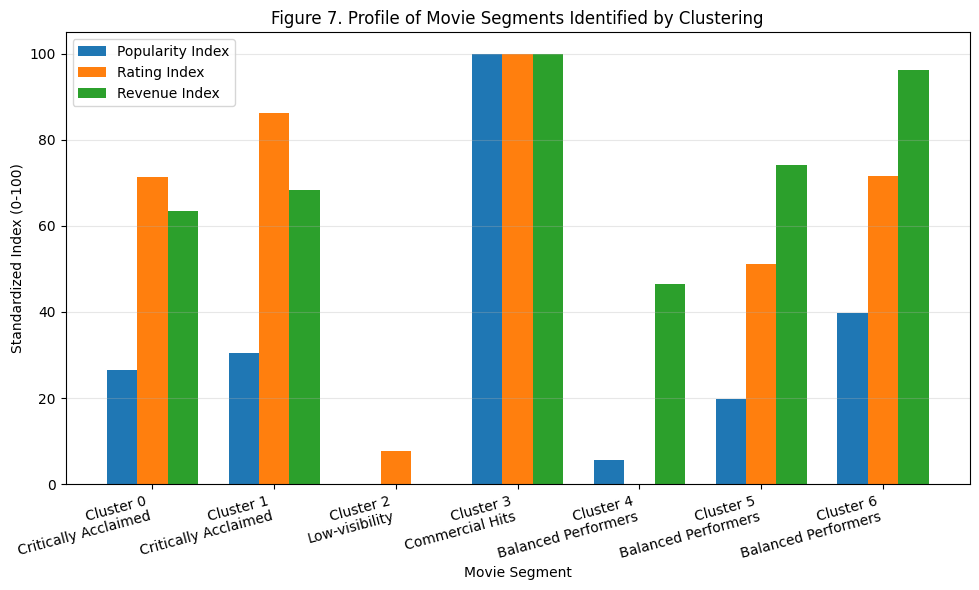

,cluster,number_of_movies,average_popularity,average_rating,average_revenue,median_revenue,average_budget,average_runtime,average_vote_count,dominant_genre,dominant_language,popularity_index,rating_index,revenue_index,segment_label
0,0,628,0.546542,4.939928,4.167473e+04,0.0,1.907246e+05,124.772293,17.092357,Action,hi,26.480336,71.258510,63.489164,Critically Acclaimed
1,1,1054,0.613948,5.649768,9.275747e+04,0.0,7.555117e+04,135.289374,16.529412,Drama,hi,30.357063,86.213674,68.264306,Critically Acclaimed
2,2,61,0.086121,1.923754,0.000000e+00,0.0,7.704098e+02,47.573770,1.295082,Documentary,hi,0.000000,7.712599,0.000000,Low-visibility
3,3,358,1.824849,6.304128,1.890812e+07,8869378.5,7.253357e+06,149.972067,137.259777,Action,hi,100.000000,100.000000,100.000000,Commercial Hits
4,4,727,0.182677,1.557680,2.432576e+03,0.0,3.226338e+05,59.852820,0.618982,Drama,hi,5.553230,0.000000,46.535778,Balanced Performers
5,5,182,0.431452,3.989231,2.498211e+05,0.0,7.744711e+05,100.005495,14.401099,Horror,hi,19.861089,51.228851,74.177430,Balanced Performers
6,6,43,0.779360,4.961814,9.921418e+06,0.0,5.434643e+06,112.209302,59.162791,Science Fiction,hi,39.870474,71.719605,96.151049,Balanced Performers


In [2]:

df_raw = load_raw_dataset()
df = prepare_base_dataframe(df_raw)
df, genre_cols = add_top_genre_columns(df)

numeric_features = [
    "runtime", "release_year", "release_month", "genre_count", "keyword_count",
    "cast_size", "production_company_count", "spoken_language_count",
    "overview_length", "tagline_length", "has_tagline",
    "log_budget", "log_revenue", "log_vote_count",
    "popularity", "vote_average"
] + genre_cols

categorical_features = ["language", "primary_genre"]

feature_cols = numeric_features + categorical_features
cluster_df = df.dropna(subset=["popularity", "vote_average"]).copy()

X = cluster_df[feature_cols]

preprocessor = make_structured_preprocessor(numeric_features, categorical_features)
X_processed = preprocessor.fit_transform(X)

# Compare k values using silhouette score.
silhouette_rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_rows.append({"k": k, "silhouette_score": score})

silhouette_table = pd.DataFrame(silhouette_rows).sort_values("silhouette_score", ascending=False)
save_table(silhouette_table, "RQ7_silhouette_scores.csv")

best_k = int(silhouette_table.iloc[0]["k"])
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_processed)

# Cluster profile table
profile = (
    cluster_df.groupby("cluster")
    .agg(
        number_of_movies=("id", "count"),
        average_popularity=("popularity", "mean"),
        average_rating=("vote_average", "mean"),
        average_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        average_budget=("budget", "mean"),
        average_runtime=("runtime", "mean"),
        average_vote_count=("vote_count", "mean"),
        dominant_genre=("primary_genre", lambda x: x.value_counts().index[0] if len(x) else "Unknown"),
        dominant_language=("language", lambda x: x.value_counts().index[0] if len(x) else "Unknown")
    )
    .reset_index()
)

# Create standardized 0-100 indices for figure.
def index_0_100(s):
    if s.max() == s.min():
        return pd.Series(np.repeat(50, len(s)), index=s.index)
    return 100 * (s - s.min()) / (s.max() - s.min())

profile["popularity_index"] = index_0_100(profile["average_popularity"])
profile["rating_index"] = index_0_100(profile["average_rating"])
profile["revenue_index"] = index_0_100(np.log1p(profile["average_revenue"].clip(lower=0)))

# Add simple segment labels
def segment_label(row):
    p, r, rev = row["popularity_index"], row["rating_index"], row["revenue_index"]
    if rev >= 70 and p >= 70:
        return "Commercial Hits"
    if r >= 70 and rev < 70:
        return "Critically Acclaimed"
    if p <= 35 and rev <= 35:
        return "Low-visibility"
    return "Balanced Performers"

profile["segment_label"] = profile.apply(segment_label, axis=1)
profile = profile.sort_values("cluster")
save_table(profile, "RQ7_cluster_profile.csv")

answer = pd.DataFrame([{
    "research_question": "RQ7",
    "actual_answer": f"K-means selected k={best_k} based on the highest silhouette score ({silhouette_table.iloc[0]['silhouette_score']:.3f}). The resulting clusters were profiled using popularity, rating, revenue, budget, runtime, dominant genre, and dominant language.",
    "best_k": best_k,
    "best_silhouette_score": silhouette_table.iloc[0]["silhouette_score"]
}])
save_table(answer, "RQ7_actual_answer.csv")

# Figure 7 grouped bar chart
plot_profile = profile.copy()
plot_profile["cluster_label"] = (
    "Cluster " + plot_profile["cluster"].astype(str) + "\n" + plot_profile["segment_label"]
)

x = np.arange(len(plot_profile))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, plot_profile["popularity_index"], width, label="Popularity Index")
ax.bar(x, plot_profile["rating_index"], width, label="Rating Index")
ax.bar(x + width, plot_profile["revenue_index"], width, label="Revenue Index")
ax.set_title("Figure 7. Profile of Movie Segments Identified by Clustering")
ax.set_xlabel("Movie Segment")
ax.set_ylabel("Standardized Index (0-100)")
ax.set_xticks(x)
ax.set_xticklabels(plot_profile["cluster_label"], rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, "RQ7_figure_cluster_profiles.pdf")
plt.show()

profile
